# ENCM 509 — Lab 7 Report
**Group:** 56
**Name:** Sadman Shahriar (30121460) Shreosi Debnath (30111867)
**UCID:** 30121460, 30111867

In [1]:
!pip install numpy scikit-learn scikit-image matplotlib opencv-python

In [2]:
import os
import numpy as np
import cv2
from skimage.io import imread
from skimage.feature import local_binary_pattern
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_curve, det_curve
import matplotlib.pyplot as plt

In [3]:
def load_all_data(base_path):
    data, labels = [], []
    for subject in range(1, 41):
        folder = os.path.join(base_path, f's{subject}')
        for img_num in range(1, 11):
            img_path = os.path.join(folder, f'{img_num}.pgm')
            img = cv2.imread(img_path, 0)
            img = cv2.resize(img, (50, 50))
            img = img.flatten().astype(np.float32) / 255.0
            data.append(img)
            labels.append(subject - 1)
    return np.array(data), np.array(labels)

In [4]:
def load_all_data_lbp(base_path, n_points=8, radius=1, grid_x=8, grid_y=8, n_bins=16):
    data, labels = [], []
    for subject in range(1, 41):
        folder = os.path.join(base_path, f's{subject}')
        for img_num in range(1, 11):
            img_path = os.path.join(folder, f'{img_num}.pgm')
            img = imread(img_path, as_gray=True)
            # resize to fixed size
            img = cv2.resize(img, (64, 64))
            lbp = local_binary_pattern(img, n_points, radius, method='uniform')
            # split into grid and compute histogram per cell
            h, w = lbp.shape
            cell_h = h // grid_y
            cell_w = w // grid_x
            features = []
            for i in range(grid_y):
                for j in range(grid_x):
                    cell = lbp[i*cell_h:(i+1)*cell_h, j*cell_w:(j+1)*cell_w]
                    hist, _ = np.histogram(cell.ravel(), bins=n_points+2,
                                           range=(0, n_points+2), density=True)
                    features.extend(hist)
            data.append(np.array(features, dtype=np.float32))
            labels.append(subject - 1)
    return np.array(data), np.array(labels)

In [5]:
base_path = 'ATT dataset'

all_data,     all_labels     = load_all_data(base_path)
all_data_lbp, all_labels_lbp = load_all_data_lbp(base_path)

# 50/50 split
#5 images per subject for training 5 for testing
train_data,     test_data,     train_label,     test_label = train_test_split(
    all_data,     all_labels,
    test_size=0.5, random_state=42, stratify=all_labels)

train_data_lbp, test_data_lbp, train_label_lbp, test_label_lbp = train_test_split(
    all_data_lbp, all_labels_lbp,
    test_size=0.5, random_state=42, stratify=all_labels_lbp)

print("Raw train:", train_data.shape,     "| test:", test_data.shape)
print("LBP train:", train_data_lbp.shape, "| test:", test_data_lbp.shape)

#Expected output:
#Raw train: (200, 2500) | test: (200, 2500)
#LBP train: (200, 64)   | test: (200, 64)

Raw train: (200, 2500) | test: (200, 2500)
LBP train: (200, 640) | test: (200, 640)


In [6]:
all_data_lbp, all_labels_lbp = load_all_data_lbp('ATT dataset', grid_x=6, grid_y=6)

train_data_lbp, test_data_lbp, train_label_lbp, test_label_lbp = train_test_split(
    all_data_lbp, all_labels_lbp,
    test_size=0.5, random_state=42, stratify=all_labels_lbp)

print("LBP feature shape:", train_data_lbp.shape)

LBP feature shape: (200, 360)


In [7]:
#SVM on raw pixels
svm_raw = SVC(C=5.0, gamma='scale', probability=True)
svm_raw.fit(train_data, train_label)
prob_svm_raw = svm_raw.predict_proba(test_data)
acc_svm_raw  = np.mean(np.argmax(prob_svm_raw, 1) == test_label)
print(f"SVM (raw):  {acc_svm_raw*100:.1f}%")

#SVM on LBP
svm_lbp = SVC(C=5.0, gamma='scale', probability=True)
svm_lbp.fit(train_data_lbp, train_label_lbp)
prob_svm_lbp = svm_lbp.predict_proba(test_data_lbp)
acc_svm_lbp  = np.mean(np.argmax(prob_svm_lbp, 1) == test_label_lbp)
print(f"SVM (LBP):  {acc_svm_lbp*100:.1f}%")

#MLP on raw pixels
mlp_raw = MLPClassifier(hidden_layer_sizes=(128, 64, 128),
                        learning_rate_init=0.001,
                        max_iter=10000,
                        random_state=1)
mlp_raw.fit(train_data, train_label)
prob_mlp_raw = mlp_raw.predict_proba(test_data)
acc_mlp_raw  = np.mean(np.argmax(prob_mlp_raw, 1) == test_label)
print(f"MLP (raw):  {acc_mlp_raw*100:.1f}%")

#MLP on LBP
mlp_lbp = MLPClassifier(hidden_layer_sizes=(128, 64, 128),
                        learning_rate_init=0.001,
                        max_iter=10000,
                        random_state=1)
mlp_lbp.fit(train_data_lbp, train_label_lbp)
prob_mlp_lbp = mlp_lbp.predict_proba(test_data_lbp)
acc_mlp_lbp  = np.mean(np.argmax(prob_mlp_lbp, 1) == test_label_lbp)
print(f"MLP (LBP):  {acc_mlp_lbp*100:.1f}%")

SVM (raw):  96.0%
SVM (LBP):  91.0%
MLP (raw):  90.0%
MLP (LBP):  73.5%


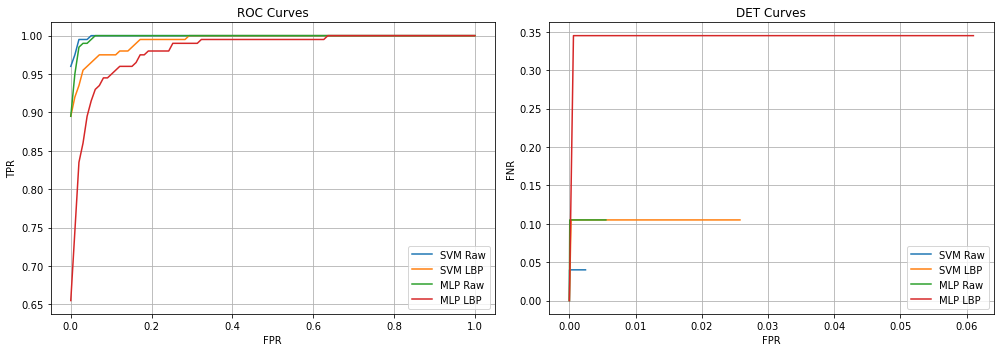

In [8]:
def compute_avg_roc_det(test_label, prob_matrix, n_subjects=40):
    roc_fpr = np.zeros((n_subjects, 100))
    roc_tpr = np.zeros((n_subjects, 100))
    det_fpr = np.zeros((n_subjects, 100))
    det_fnr = np.zeros((n_subjects, 100))
    for i in range(n_subjects):
        binary = (test_label == i).astype(int)
        fpr, tpr, _ = roc_curve(binary, prob_matrix[:, i])
        roc_fpr[i] = np.linspace(fpr.min(), fpr.max(), 100)
        roc_tpr[i] = np.interp(roc_fpr[i], fpr, tpr)
        fpr2, fnr, _ = det_curve(binary, prob_matrix[:, i])
        det_fpr[i] = np.linspace(fpr2.min(), fpr2.max(), 100)
        det_fnr[i] = np.interp(det_fpr[i], fpr2, fnr)
    return (np.mean(roc_fpr, 0), np.mean(roc_tpr, 0),
            np.mean(det_fpr, 0), np.mean(det_fnr, 0))

models = {
    "SVM Raw": (prob_svm_raw, test_label),
    "SVM LBP": (prob_svm_lbp, test_label_lbp),
    "MLP Raw": (prob_mlp_raw, test_label),
    "MLP LBP": (prob_mlp_lbp, test_label_lbp),
}

fig, (ax_roc, ax_det) = plt.subplots(1, 2, figsize=(14, 5))

for name, (prob, labels) in models.items():
    rx, ry, dx, dy = compute_avg_roc_det(labels, prob)
    ax_roc.plot(rx, ry, label=name)
    ax_det.plot(dx, dy, label=name)

ax_roc.set_xlabel('FPR')
ax_roc.set_ylabel('TPR')
ax_roc.set_title('ROC Curves')
ax_roc.legend()
ax_roc.grid(True)

ax_det.set_xlabel('FPR')
ax_det.set_ylabel('FNR')
ax_det.set_title('DET Curves')
ax_det.legend()
ax_det.grid(True)

plt.tight_layout()
plt.savefig('roc_det_curves.png', dpi=150)
plt.show()

In [9]:
print("=" * 40)
print(f"{'Model':<18} {'Accuracy':>10}")
print("=" * 40)
for name, acc in [("SVM (raw pixels)", acc_svm_raw),
                  ("SVM (LBP)",        acc_svm_lbp),
                  ("MLP (raw pixels)", acc_mlp_raw),
                  ("MLP (LBP)",        acc_mlp_lbp)]:
    print(f"{name:<18} {acc*100:>9.1f}%")
print("=" * 40)

Model                Accuracy
SVM (raw pixels)        96.0%
SVM (LBP)               91.0%
MLP (raw pixels)        90.0%
MLP (LBP)               73.5%


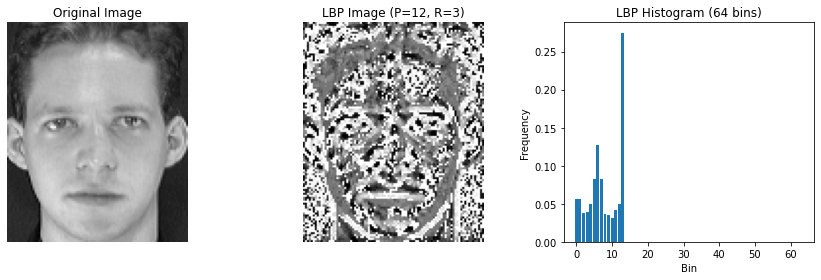

In [10]:
sample = imread('ATT dataset/s1/1.pgm', as_gray=True)
lbp_sample = local_binary_pattern(sample, 12, 3, method='uniform')

fig, axes = plt.subplots(1, 3, figsize=(12, 4))

axes[0].imshow(sample, cmap='gray')
axes[0].set_title('Original Image')
axes[0].axis('off')

axes[1].imshow(lbp_sample, cmap='gray')
axes[1].set_title('LBP Image (P=12, R=3)')
axes[1].axis('off')

hist, _ = np.histogram(lbp_sample.ravel(), bins=64, range=(0, 64), density=True)
axes[2].bar(range(64), hist)
axes[2].set_title('LBP Histogram (64 bins)')
axes[2].set_xlabel('Bin')
axes[2].set_ylabel('Frequency')

plt.tight_layout()
plt.savefig('lbp_visualization.png', dpi=150)
plt.show()

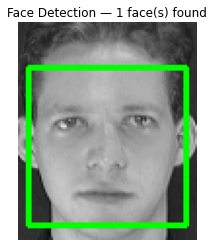

In [11]:
face_cascade = cv2.CascadeClassifier(
    cv2.data.haarcascades + 'haarcascade_frontalface_default.xml')

img = cv2.imread('ATT dataset/s1/1.pgm')
img_gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
faces = face_cascade.detectMultiScale(img_gray, 1.1, 4)

img_display = img.copy()
for (x, y, w, h) in faces:
    cv2.rectangle(img_display, (x, y), (x+w, y+h), (0, 255, 0), 2)

plt.figure(figsize=(4, 4))
plt.imshow(cv2.cvtColor(img_display, cv2.COLOR_BGR2RGB), cmap='gray')
plt.title(f'Face Detection — {len(faces)} face(s) found')
plt.axis('off')
plt.savefig('face_detection.png', dpi=150)
plt.show()


Grid=4x4: 87.5%
Grid=6x6: 90.5%
Grid=8x8: 91.0%
Grid=10x10: 90.5%


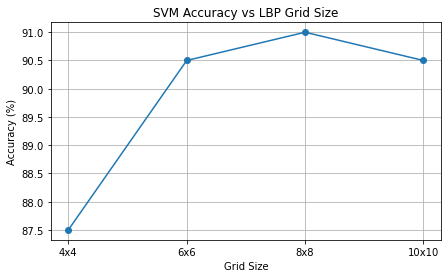

In [12]:
bin_results = {}
for grid in [4, 6, 8, 10]:
    d_lbp, l_lbp = load_all_data_lbp('ATT dataset', grid_x=grid, grid_y=grid)
    tr_d, te_d, tr_l, te_l = train_test_split(d_lbp, l_lbp,
                              test_size=0.5, random_state=42, stratify=l_lbp)
    svm = SVC(C=5.0, gamma='scale', probability=True)
    svm.fit(tr_d, tr_l)
    acc = np.mean(np.argmax(svm.predict_proba(te_d), 1) == te_l)
    bin_results[grid] = acc
    print(f"Grid={grid}x{grid}: {acc*100:.1f}%")

plt.figure(figsize=(7, 4))
plt.plot([f"{g}x{g}" for g in bin_results.keys()], [v*100 for v in bin_results.values()], marker='o')
plt.xlabel('Grid Size')
plt.ylabel('Accuracy (%)')
plt.title('SVM Accuracy vs LBP Grid Size')
plt.grid(True)
plt.savefig('lbp_bins_experiment.png', dpi=150)
plt.show()

In [16]:
param_combos = [
    (0.1, 0.001), (1.0, 0.001), (5.0, 0.001),
    (5.0, 0.01),  (5.0, 0.1),   (10.0, 0.001)
]

print(f"{'C':<8} {'gamma':<10} {'Acc Raw':>10} {'Acc LBP':>10}")
print("-" * 42)
for C, gamma in param_combos:
    s1 = SVC(C=C, gamma=gamma, probability=True)
    s1.fit(train_data, train_label)
    acc_r = np.mean(np.argmax(s1.predict_proba(test_data), 1) == test_label)

    # LBP uses gamma='scale' because feature dimensions are different
    s2 = SVC(C=C, gamma='scale', probability=True)
    s2.fit(train_data_lbp, train_label_lbp)
    acc_l = np.mean(np.argmax(s2.predict_proba(test_data_lbp), 1) == test_label_lbp)

    print(f"{C:<8} {gamma:<10} {acc_r*100:>9.1f}% {acc_l*100:>9.1f}%")

C        gamma         Acc Raw    Acc LBP
------------------------------------------
0.1      0.001            0.0%       0.0%
1.0      0.001            0.0%      80.0%
5.0      0.001           92.0%      91.0%
5.0      0.01            95.5%      90.0%
5.0      0.1             42.0%      88.5%
10.0     0.001           94.5%      90.5%


In [15]:
architectures = [
    (64,),
    (128,),
    (128, 64),
    (128, 64, 128),
    (256, 128, 64),
]

print(f"{'Architecture':<20} {'LR':<8} {'Acc Raw':>10} {'Acc LBP':>10}")
print("-" * 52)
for layers in architectures:
    for lr in [0.001, 0.01]:
        m1 = MLPClassifier(hidden_layer_sizes=layers, learning_rate_init=lr,
                           max_iter=5000, random_state=1)
        m1.fit(train_data, train_label)
        acc_r = np.mean(np.argmax(m1.predict_proba(test_data), 1) == test_label)

        m2 = MLPClassifier(hidden_layer_sizes=layers, learning_rate_init=lr,
                           max_iter=5000, random_state=1)
        m2.fit(train_data_lbp, train_label_lbp)
        acc_l = np.mean(np.argmax(m2.predict_proba(test_data_lbp), 1) == test_label_lbp)

        print(f"{str(layers):<20} {lr:<8} {acc_r*100:>9.1f}% {acc_l*100:>9.1f}%")

Architecture         LR          Acc Raw    Acc LBP
----------------------------------------------------
(64,)                0.001         93.0%      90.0%
(64,)                0.01          54.0%      87.5%
(128,)               0.001         94.5%      92.0%
(128,)               0.01          94.5%      91.0%
(128, 64)            0.001         91.5%      86.0%
(128, 64)            0.01          83.5%      79.0%
(128, 64, 128)       0.001         90.0%      73.5%
(128, 64, 128)       0.01          63.0%      69.5%
(256, 128, 64)       0.001         89.0%      77.5%
(256, 128, 64)       0.01          84.0%      70.0%
